In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from my_transforms import TransformDataset, AddGaussianNoise, AddBlockGaussianNoise
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import time
import binascii
import re

In [ ]:
# Configuration
dataset_dir = "../dataset_processed"
img_size = (128, 128)
batch_size = 64
total_classes = 15
total_epochs = 500
# warmup_epochs = 5
device = torch.device('mps')

In [3]:
# load dataset
dataset = ImageFolder(dataset_dir)

# Split into train and validation
train_subset, val_subset = random_split(
    dataset,
    [0.8, 0.2],
    generator=torch.Generator().manual_seed(42)
)

# Data transforms
train_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    AddBlockGaussianNoise(mean=0, std=0.05, block_size=4),
    transforms.ColorJitter(brightness=0.5),
])

val_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize(img_size),
    transforms.ToTensor(),
])

train_dataset = TransformDataset(train_subset, transform=train_transform)
val_dataset = TransformDataset(val_subset, transform=val_transform)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=8,
    persistent_workers=True,
    prefetch_factor=4
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=8,
    persistent_workers=True,
    prefetch_factor=4
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 9600
Validation samples: 2400


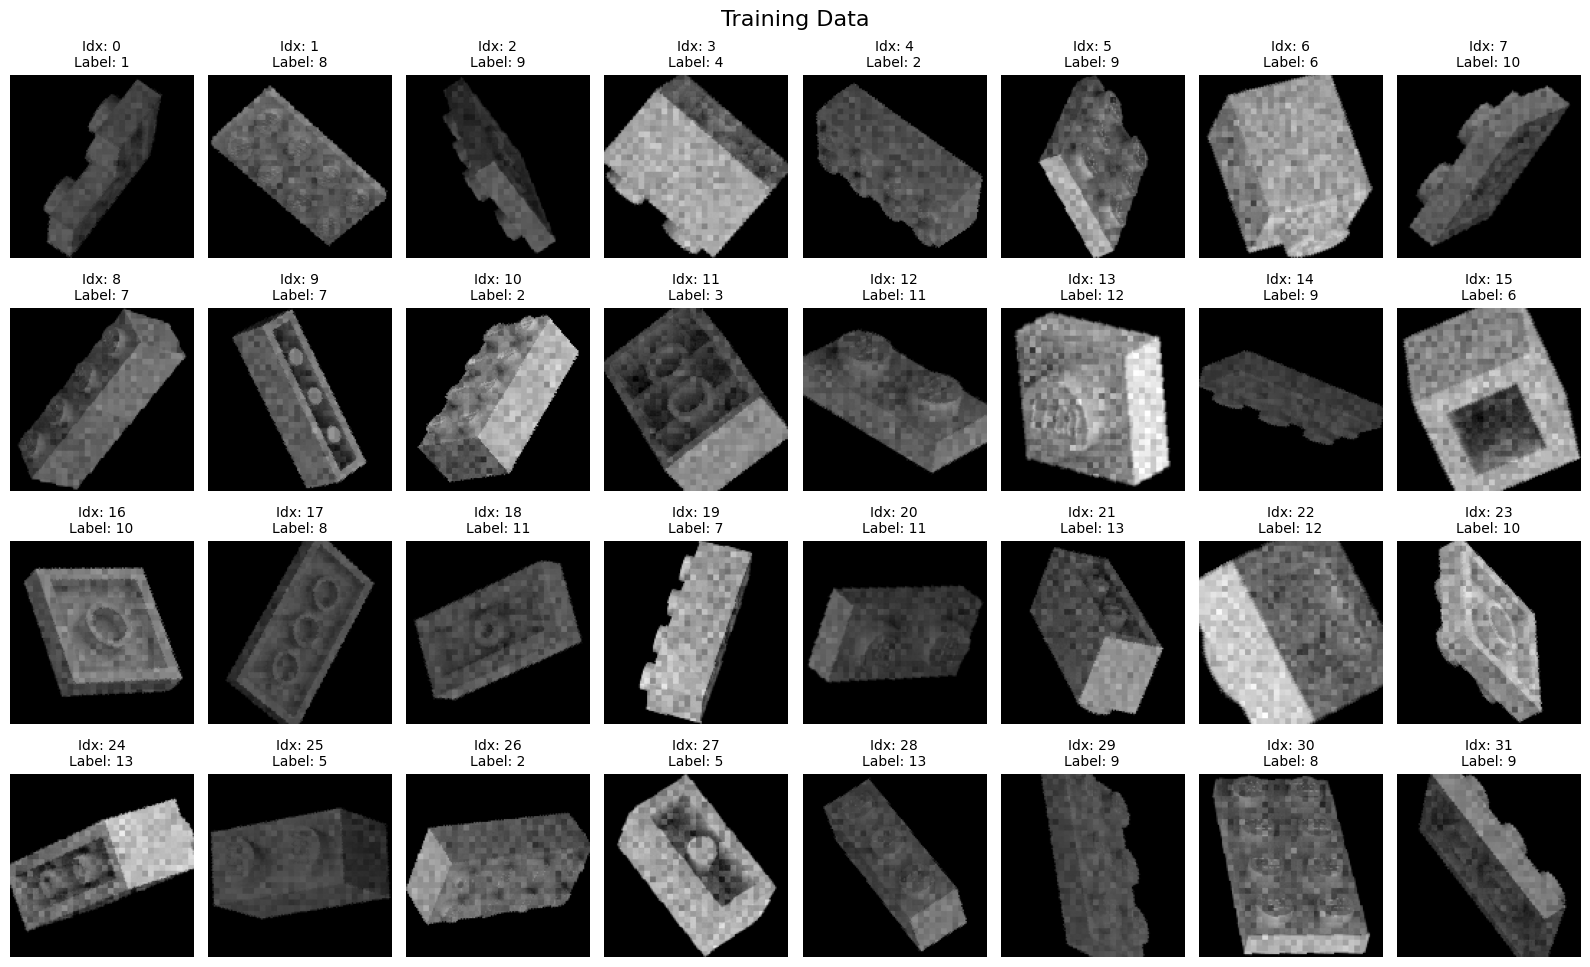

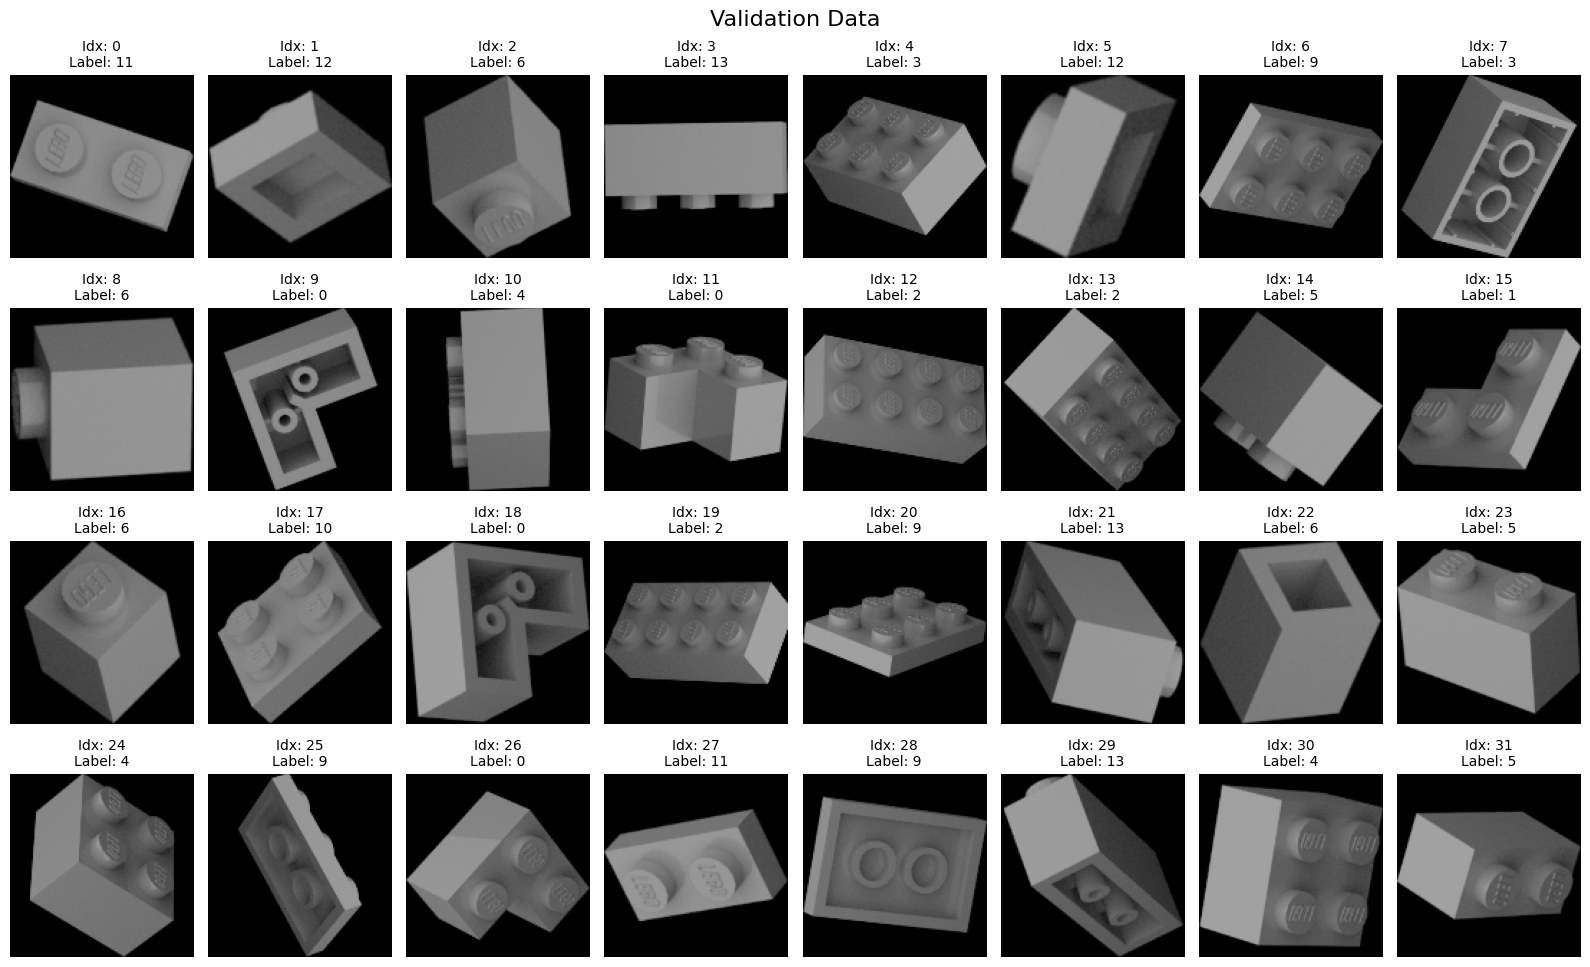

In [4]:
def visualize_dataset(dataset, title="Dataset Preview", rows=4, cols=8, start_idx=0):
    # Calculate indices
    num_samples = rows * cols
    max_idx = len(dataset)
    indices = range(start_idx, min(start_idx + num_samples, max_idx))
    
    # Setup the figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2.5))
    fig.suptitle(title, fontsize=16)
    
    # Flatten axes array for easy iteration
    axes_flat = axes.flatten()
    
    for i, ax in enumerate(axes_flat):
        if i < len(indices):
            idx = indices[i]
            img, label = dataset[idx]
            
            # Convert Tensor (C, H, W) -> Numpy (H, W) or (H, W, C)
            img_np = img.squeeze().cpu().numpy()
            
            ax.imshow(img_np, cmap='gray', vmin=0, vmax=1)
            ax.set_title(f"Idx: {idx}\nLabel: {label}", fontsize=10)
        
        # Turn off axis for all subplots (even empty ones)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_dataset(train_dataset, title="Training Data")
visualize_dataset(val_dataset, title="Validation Data")

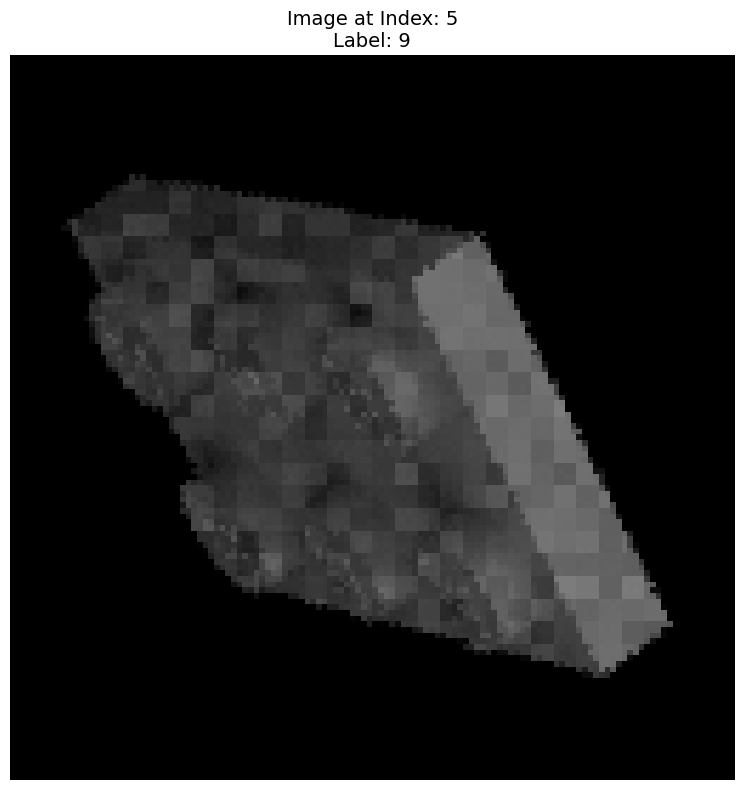

In [5]:
def show_single_image(dataset, index):
    if index < 0 or index >= len(dataset):
        print(f"Error: Index {index} is out of range. Dataset has {len(dataset)} images.")
        return
    
    # Get image and label
    img, label = dataset[index]
    img_np = img.squeeze().cpu().numpy()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img_np, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"Image at Index: {index}\nLabel: {label}", fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

show_single_image(train_dataset, index=5)

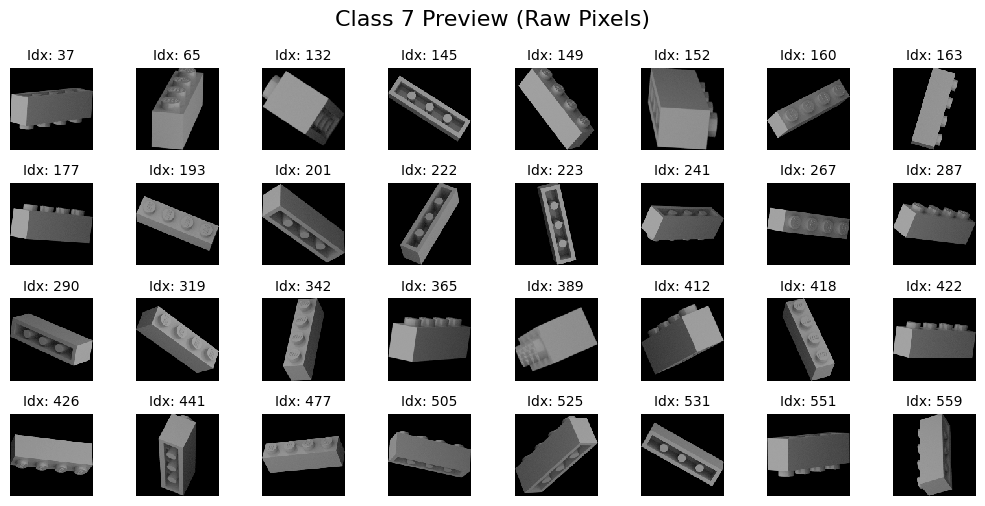

In [6]:
def visualize_specific_class(dataset, target_class, rows=4, cols=8):
    # Get the actual image dimensions from the first image
    sample_img, _ = dataset[0]
    img_height, img_width = sample_img.shape[-2:]  # Handle both CHW and HW formats
    
    # Calculate figure size to match exact pixel dimensions
    # Each subplot should be exactly the size of one image
    dpi = 100  # Standard DPI
    fig_width = (img_width * cols) / dpi
    fig_height = (img_height * rows) / dpi
    
    fig, axes = plt.subplots(rows, cols, figsize=(fig_width, fig_height), dpi=dpi)
    fig.suptitle(f"Class {target_class} Preview (Raw Pixels)", fontsize=16)
    axes_flat = axes.flatten()
    
    count = 0
    total_slots = rows * cols
    
    for i in range(len(dataset)):
        img, label = dataset[i]
        
        if label == target_class:
            ax = axes_flat[count]
            img_np = img.squeeze().cpu().numpy()
            
            # CRITICAL: Use interpolation='nearest' and turn off antialiasing
            ax.imshow(img_np, cmap='gray', vmin=0, vmax=1, 
                     interpolation='nearest',  # or 'none' - both work
                     resample=False)  # Disable PIL resampling
            
            ax.set_title(f"Idx: {i}", fontsize=10)
            ax.axis('off')
            
            count += 1
            if count >= total_slots:
                break
    
    # Hide unused subplots
    for j in range(count, total_slots):
        axes_flat[j].axis('off')
    
    plt.tight_layout()
    plt.show()

# Usage
visualize_specific_class(val_dataset, target_class=7)

In [7]:
# Training plotter
class TrainingPlotter:
    def __init__(self, figsize=(15, 5)):
        self.fig, (self.ax1, self.ax2) = plt.subplots(1, 2, figsize=figsize)
        self.display_handle = None
    
    def update(self, epoch_data, train_loss, val_loss, train_acc, val_acc):
        # Clear both axes
        self.ax1.cla()
        self.ax2.cla()
        
        # Plot loss
        self.ax1.plot(epoch_data, train_loss, 'b-', label='Train', linewidth=2, marker='o', markersize=3)
        self.ax1.plot(epoch_data, val_loss, 'r-', label='Validation', linewidth=2, marker='s', markersize=4)
        self.ax1.set_xlabel('Epoch')
        self.ax1.set_ylabel('Loss')
        self.ax1.set_title('Loss')
        self.ax1.legend()
        self.ax1.grid(True, alpha=0.3)
        
        # Plot accuracy
        self.ax2.plot(epoch_data, train_acc, 'b-', label='Train', linewidth=2, marker='o', markersize=3)
        self.ax2.plot(epoch_data, val_acc, 'r-', label='Validation', linewidth=2, marker='s', markersize=4)
        self.ax2.set_xlabel('Epoch')
        self.ax2.set_ylabel('Accuracy (%)')
        self.ax2.set_title('Accuracy')
        self.ax2.legend()
        self.ax2.grid(True, alpha=0.3)
        
        # Display only on first update
        if self.display_handle is None:
            self.display_handle = display(self.fig, display_id=True)
        else:
            self.display_handle.update(self.fig)
    
    def close(self):
        plt.close(self.fig)

# Progress bar function
def print_progress(batch_idx, total_batches, metrics, elapsed_time, prefix=""):
    GREEN = '\033[92m'
    RESET = '\033[0m'

    """Print modern Keras-style progress bar"""
    progress = (batch_idx + 1) / total_batches
    bar_length = 20
    filled = int(bar_length * progress)
    
    # Use Unicode box drawing characters
    bar = f"{GREEN}{'━' * filled}{RESET}" + '━' * (bar_length - filled)
    
    # Calculate time per step
    time_per_step = (elapsed_time / (batch_idx + 1)) * 1000  # in ms
    
    # Estimate time remaining
    eta = int((elapsed_time / (batch_idx + 1)) * (total_batches - batch_idx - 1))
    
    # Build metrics string    
    metrics_str = ' - '.join([
        f"loss: {metrics['loss']:.4f}",
        f"accuracy: {metrics['accuracy']:.2f}%"
    ])
    
    print(f'\r{batch_idx + 1:3d}/{total_batches:3d} {bar} {int(eta):2d}s {int(time_per_step):3d}ms/step {prefix} - {metrics_str}', 
          end='    ', flush=True)

In [8]:
# TODO: huge code duplication

# Training function with progress bar
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    start_time = time.time()
    total_batches = len(loader)
    
    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        loss_stat = running_loss / total
        accuracy_stat = 100.0 * correct / total
        
        # Print progress bar
        elapsed = time.time() - start_time
        metrics = {
            'loss': loss_stat,
            'accuracy': accuracy_stat
        }
        print_progress(batch_idx, total_batches, metrics, elapsed, "Train")
    
    print()  # New line after progress bar
    epoch_loss = loss_stat
    epoch_acc = accuracy_stat
    return epoch_loss, epoch_acc

# Validation function
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    start_time = time.time()
    total_batches = len(loader)
    
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            loss_stat = running_loss / total
            accuracy_stat = 100.0 * correct / total
            
            # Print progress bar for validation
            elapsed = time.time() - start_time
            metrics = {
                'loss': loss_stat,
                'accuracy': accuracy_stat
            }
            print_progress(batch_idx, total_batches, metrics, elapsed, "Valid")
    
    print()  # New line after progress bar
    epoch_loss = loss_stat
    epoch_acc = accuracy_stat
    return epoch_loss, epoch_acc

In [9]:
# like 75% accuracy in validation

# class LegoClassifier(nn.Module):
#     def __init__(self, num_classes):
#         super(LegoClassifier, self).__init__()
        
#         self.net = nn.Sequential(
#             # Block 1
#             nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
#             nn.BatchNorm2d(16),
#             nn.ReLU(),
            
#             nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1),
#             nn.BatchNorm2d(16),
#             nn.ReLU(),
            
#             # Block 2
#             nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
            
#             nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
            
#             # Block 3
#             nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
            
#             nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
            
#             # Global pooling
#             nn.AdaptiveAvgPool2d((1, 1)),
#             nn.Dropout(0.2),
#             nn.Flatten(),
#             nn.Linear(64, num_classes)
#         )
    
#     def forward(self, x):
#         return self.net(x)

In [10]:
# Model definition
class LegoClassifier(nn.Module):
    def __init__(self, num_classes):
        super(LegoClassifier, self).__init__()
        channels_per_group = 16
        self.net = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1), nn.GroupNorm(32 // channels_per_group, 32), nn.LeakyReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1), nn.GroupNorm(32 // channels_per_group, 32), nn.LeakyReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), nn.GroupNorm(64 // channels_per_group, 64), nn.LeakyReLU(),
            # nn.Dropout2d(0.1),
            
            # Block 2
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1), nn.GroupNorm(64 // channels_per_group, 64), nn.LeakyReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1), nn.GroupNorm(64 // channels_per_group, 64), nn.LeakyReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1), nn.GroupNorm(64 // channels_per_group, 64), nn.LeakyReLU(),
            nn.Dropout2d(0.1),
            
            # Block 3
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1), nn.GroupNorm(64 // channels_per_group, 64), nn.LeakyReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1), nn.GroupNorm(64 // channels_per_group, 64), nn.LeakyReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), nn.GroupNorm(128 // channels_per_group, 128), nn.LeakyReLU(),
            nn.Dropout2d(0.2),
            
            # Global pooling
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

In [11]:
model = LegoClassifier(total_classes).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 289,647


Model parameters: 289,647
Training on mps


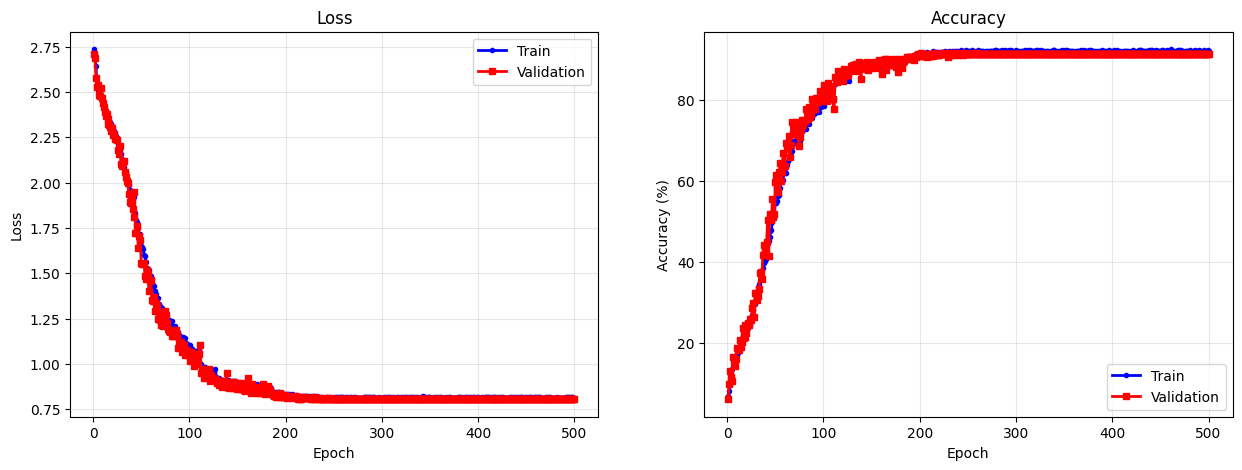

Epoch 1/500 | LR: 0.050000
150/150 ━━━━━━━━━━━━━━━━━━━━  0s 108ms/step Train - loss: 2.7362 - accuracy: 6.95%       
 38/ 38 ━━━━━━━━━━━━━━━━━━━━  0s 211ms/step Valid - loss: 2.7075 - accuracy: 6.08%      
----------------------------------------------------------------------------------
Epoch 2/500 | LR: 0.050000
150/150 ━━━━━━━━━━━━━━━━━━━━  0s  64ms/step Train - loss: 2.7021 - accuracy: 8.12%     
 38/ 38 ━━━━━━━━━━━━━━━━━━━━  0s  27ms/step Valid - loss: 2.6892 - accuracy: 9.96%     
----------------------------------------------------------------------------------
Epoch 3/500 | LR: 0.050000
150/150 ━━━━━━━━━━━━━━━━━━━━  0s  69ms/step Train - loss: 2.6432 - accuracy: 9.57%     
 38/ 38 ━━━━━━━━━━━━━━━━━━━━  0s  28ms/step Valid - loss: 2.5797 - accuracy: 13.17%    
----------------------------------------------------------------------------------
Epoch 4/500 | LR: 0.050000
150/150 ━━━━━━━━━━━━━━━━━━━━  0s  67ms/step Train - loss: 2.5352 - accuracy: 13.07%    
 38/ 38 ━━━━━━━━━━━━━━━━

In [12]:
# Initialize model
model = LegoClassifier(total_classes).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Loss and optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(
    model.parameters(),
    lr=0.05,
    momentum=0.9,
    weight_decay=1e-5
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',           # Monitor loss (use 'max' for accuracy)
    factor=0.5,           # Reduce LR by 50% (new_lr = lr * 0.5)
    patience=5,           # Wait 5 epochs before reducing
    threshold=0.0001,     # Minimum change to qualify as improvement
    threshold_mode='rel', # Relative threshold (0.01%)
    cooldown=2,           # Wait 2 epochs after reduction before monitoring again
    min_lr=1e-6,          # Don't go below this
)

# Training loop
history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# Initialize plotter
plotter = TrainingPlotter(figsize=(15, 5))

print(f"Training on {device}")

# show plotter first
plotter.update([], [], [], [], [])

for epoch in range(total_epochs):
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{total_epochs} | "
          f"LR: {current_lr:.6f}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Store history
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Update learning rate
    scheduler.step(val_loss)
    
    # Update plot
    plotter.update(
        history['epoch'],
        history['train_loss'],
        history['val_loss'],
        history['train_acc'],
        history['val_acc']
    )
    
    print("-" * 82)

print("Training complete!")

plotter.close()

In [13]:
# Save model
torch.save(model.state_dict(), 'lego_classifier.pth')
print("\nModel saved to 'lego_classifier.pth'")


Model saved to 'lego_classifier.pth'


In [14]:
# 1. Instantiate the empty model structure (Must match the saved model exactly)
model = LegoClassifier(num_classes=total_classes)

# 2. Load the weights dictionary
model.load_state_dict(torch.load('lego_classifier.pth'))

# 3. Set to eval mode (Crucial for Batch Norm / Dropout layers)
model.eval()

print("Weights loaded successfully!")

Weights loaded successfully!


In [15]:
# TODO: as soon as this is imported dataloaders with num_workers > 0 fail
import ai_edge_torch

/Users/ety/Documents/ai-master/2025/semester-1/edge-computing/.venv/lib/python3.11/site-packages/torch/distributed/distributed_c10d.py:351: UserWarning: Device capability of jax unspecified, assuming `cpu` and `cuda`. Please specify it via the `devices` argument of `register_backend`.
  warnings.warn(
/Users/ety/Documents/ai-master/2025/semester-1/edge-computing/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
def convert_and_export_full_int8(model, dataloader, output_name="lego_model"):
    """
    Converts PyTorch model to TFLite with Full Integer Quantization 
    (mimicking Keras representative_dataset logic) and generates C header.
    """
    
    print("1. Preparing Calibration Data...")
    calibration_data = []
    count = 0
    # Collect 20 batches for calibration
    for images, _ in dataloader:
        calibration_data.append(images.cpu().numpy())
        count += 1
        if count >= 20: break
    
    # Define the generator for TFLite
    def representative_dataset_gen():
        for img_np in calibration_data:
            # Yield as list of arguments [input_tensor]
            yield [img_np]

    print("2. Converting PyTorch -> TFLite (Full Int8 Quantization)...")
    
    # Prepare model
    model = model.to('cpu')
    model.eval()
    
    # Sample input for shape inference
    sample_input = (torch.tensor(calibration_data[0]),)

    # Converter Flags (Exact equivalent to your Keras code)
    tfl_converter_flags = {
        "optimizations": [tf.lite.Optimize.DEFAULT],
        "representative_dataset": representative_dataset_gen,
        # Force operations to be Int8 supported
        "target_spec": {
            "supported_ops": [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        },
        # Input: Uint8 (0-255) -> Perfect for Camera data
        "inference_input_type": tf.uint8, 
        # Output: Int8 or Uint8 (doesn't matter much for ArgMax, but let's match)
        "inference_output_type": tf.uint8
    }
    
    # Convert
    edge_model = ai_edge_torch.convert(
        model,
        sample_input,
        _ai_edge_converter_flags=tfl_converter_flags
    )
    
    # Export
    tflite_filename = f"{output_name}.tflite"
    edge_model.export(tflite_filename)
    
    quant_size = os.path.getsize(tflite_filename) / 1024
    print(f"✔ Created Int8 model: {quant_size:.2f} KB")

    # ==========================================
    # 3. GENERATE ARDUINO HEADER
    # ==========================================
    print("\n3. Generating C Header...")

    with open(tflite_filename, "rb") as f:
        model_bytes = f.read()

    hex_str = binascii.hexlify(model_bytes).decode("ascii")
    formatted_hex = re.sub(r"(..)", r"0x\1, ", hex_str)
    formatted_hex = re.sub(r"(.{72})", r"\1\n    ", formatted_hex)

    header_content = f"""
#ifdef __has_attribute
#define HAVE_ATTRIBUTE(x) __has_attribute(x)
#else
#define HAVE_ATTRIBUTE(x) 0
#endif

#if HAVE_ATTRIBUTE(aligned) || (defined(__GNUC__) && !defined(__clang__))
#define DATA_ALIGN_ATTRIBUTE __attribute__((aligned(4)))
#else
#define DATA_ALIGN_ATTRIBUTE
#endif

const int {output_name}_len = {len(model_bytes)};
DATA_ALIGN_ATTRIBUTE const unsigned char {output_name}[] = {{
    {formatted_hex}
}};
"""
    header_filename = f"{output_name}.h"
    with open(header_filename, "w") as f:
        f.write(header_content)

    print(f"✔ Success! {header_filename} is ready.")

# --- USAGE ---

val_loader_single = DataLoader(
    val_loader.dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
)

convert_and_export_full_int8(model, val_loader_single, "lego_model")

1. Preparing Calibration Data...
2. Converting PyTorch -> TFLite (Full Int8 Quantization)...
INFO:tensorflow:Assets written to: /var/folders/hw/y_6w8_lx6y12b38jlylsd47r0000gn/T/tmpiyvij9df/assets


INFO:tensorflow:Assets written to: /var/folders/hw/y_6w8_lx6y12b38jlylsd47r0000gn/T/tmpiyvij9df/assets
W0000 00:00:1765897973.018988 16277877 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1765897973.019001 16277877 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1765897973.019127 16277877 reader.cc:83] Reading SavedModel from: /var/folders/hw/y_6w8_lx6y12b38jlylsd47r0000gn/T/tmpiyvij9df
I0000 00:00:1765897973.019434 16277877 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1765897973.019436 16277877 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/hw/y_6w8_lx6y12b38jlylsd47r0000gn/T/tmpiyvij9df
I0000 00:00:1765897973.022096 16277877 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1765897973.037892 16277877 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/hw/y_6w8_lx6y12b38jlylsd47r0000gn/T/tmpiyvij9df
I0000 00:00:1765897973.042370 16277877 loader.

✔ Created Int8 model: 375.75 KB

3. Generating C Header...
✔ Success! lego_model.h is ready.


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8
I0000 00:00:1765897975.315886 16277877 flatbuffer_export.cc:4160] Estimated count of arithmetic ops: 534.779 M  ops, equivalently 267.390 M  MACs
W0000 00:00:1765897975.315899 16277877 flatbuffer_export.cc:3715] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def test_tflite_inference(tflite_model_path, dataset, index):
    """
    Run inference on a TFLite model that expects Uint8 [0-255] input.
    """
    
    if index < 0 or index >= len(dataset):
        print(f"Error: Index {index} is out of range.")
        return

    # --- 1. SETUP INTERPRETER ---
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    
    input_index = input_details['index']
    output_index = output_details['index']

    # --- 2. PREPARE INPUT (0.0-1.0 Float -> 0-255 Uint8) ---
    img, true_label = dataset[index]
    
    # Get float image (0.0 to 1.0)
    img_np = img.cpu().numpy()
    
    if len(img_np.shape) == 3:
        img_np = np.expand_dims(img_np, axis=0)

    # DIRECT SCALING: No quantization params needed. 
    # The model wants raw pixels (0-255).
    input_uint8 = (img_np * 255).astype(np.uint8)

    # --- 3. RUN INFERENCE ---
    interpreter.set_tensor(input_index, input_uint8)
    interpreter.invoke()
    
    # --- 4. PROCESS OUTPUT ---
    # Output is Uint8 (0-255) representing probability
    output_uint8 = interpreter.get_tensor(output_index)
    
    # We only need to scale back to float for the "% Confidence" display.
    # We can trust the model's output params for this mapping.
    out_scale, out_zero_point = output_details['quantization']
    output_float = (output_uint8.astype(np.float32) - out_zero_point) * out_scale

    # Softmax (Standard conversion from raw scores to probabilities)
    raw_output = output_float[0]
    exp_vals = np.exp(raw_output - np.max(raw_output)) 
    probabilities = exp_vals / np.sum(exp_vals)
    
    predicted_class = np.argmax(probabilities)
    predicted_prob = probabilities[predicted_class]
    top5_indices = np.argsort(probabilities)[-5:][::-1]
    top5_probs = probabilities[top5_indices]

    # --- 5. DISPLAY ---
    print("="*50)
    print(f"INFERENCE RESULTS FOR IMAGE INDEX {index} (TFLITE UINT8)")
    print("="*50)
    print(f"True Label:      {true_label}")
    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence:      {predicted_prob*100:.2f}%")
    print(f"Correct:         {'✓ YES' if predicted_class == true_label else '✗ NO'}")
    print("\nTop 5 Predictions:")
    for i, (prob, cls) in enumerate(zip(top5_probs, top5_indices)):
        marker = "→" if cls == true_label else " "
        print(f"{marker} {i+1}. Class {cls:2d}: {prob*100:5.2f}%")
    
    # Visualize
    img_disp = img.squeeze().cpu().numpy()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.imshow(img_disp, cmap='gray', vmin=0, vmax=1)
    ax1.set_title(f"Input Image (Index: {index})\nTrue Label: {true_label}", fontsize=12)
    ax1.axis('off')
    
    top5_classes_list = list(top5_indices)
    top5_probs_list = [p * 100 for p in top5_probs]
    colors = ['green' if c == true_label else 'blue' for c in top5_classes_list]
    
    ax2.barh(range(5), top5_probs_list, color=colors)
    ax2.set_yticks(range(5))
    ax2.set_yticklabels([f"Class {c}" for c in top5_classes_list])
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title(f"Predicted: Class {predicted_class} ({predicted_prob*100:.1f}%)", fontsize=12)
    ax2.set_xlim(0, 100)
    ax2.invert_yaxis()
    
    for i, (prob, cls) in enumerate(zip(top5_probs_list, top5_classes_list)):
        ax2.text(prob + 1, i, f'{prob:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()
    
    return predicted_class, predicted_prob, true_label

In [24]:
def export_image_array(dataset, index):    
    if index < 0 or index >= len(dataset):
        print(f"Error: Index {index} is out of range. Dataset has {len(dataset)} images.")
        return
    
    # Get image and label
    img, label = dataset[index]
    img_np = img.squeeze().cpu().numpy()
    
    # Get dimensions
    height, width = img_np.shape
    
    # Convert to 8-bit grayscale (0-255)
    img_uint8 = (img_np * 255).astype(np.uint8)
    
    # Flatten the image
    img_flat = img_uint8.flatten()
    
    # Create the array string
    array_content = f"const uint8_t camera_image[{len(img_flat)}] = {{\n"
    
    # Add pixel data in rows of 16 values
    for i in range(0, len(img_flat), 16):
        row = img_flat[i:i+16]
        row_str = ", ".join(f"{val:3d}" for val in row)
        array_content += f"    {row_str}"
        if i + 16 < len(img_flat):
            array_content += ","
        array_content += "\n"
    
    array_content += "};\n"
    
    # Print to console so you can copy it
    print(array_content)
    
    # Also save to file
    with open("camera_image_array.txt", 'w') as f:
        f.write(array_content)
    
    print(f"\n✓ Array saved to 'camera_image_array.txt'")
    print(f"  - Image index: {index}, Label: {label}")
    print(f"  - Dimensions: {width}x{height}")
    print(f"  - Total bytes: {len(img_flat)}")

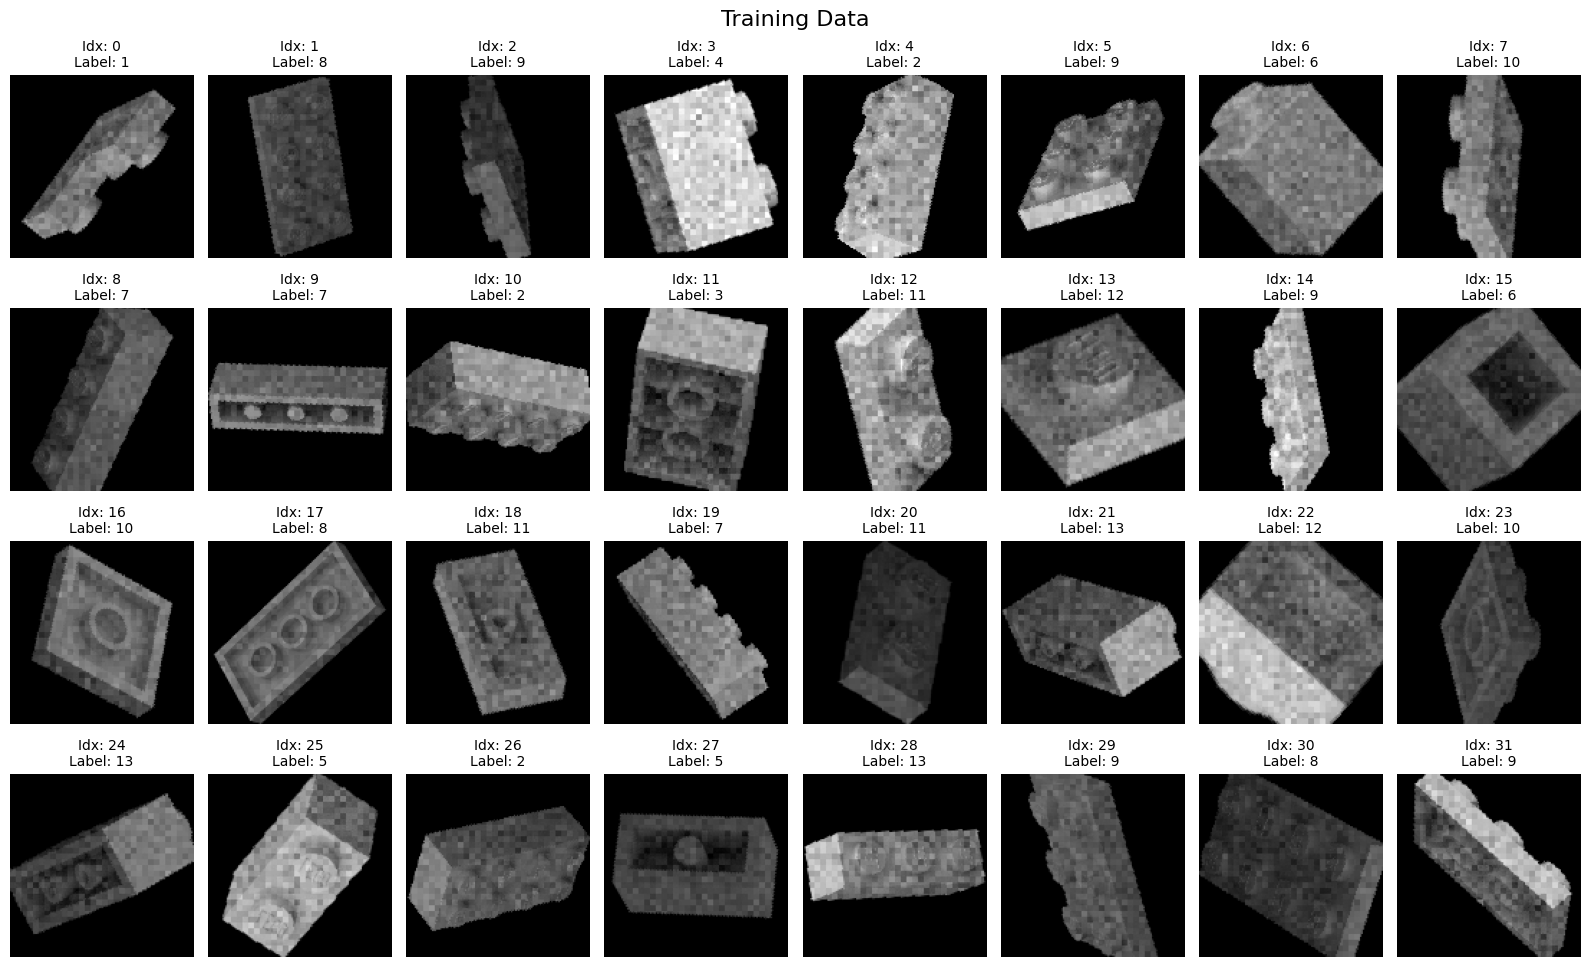

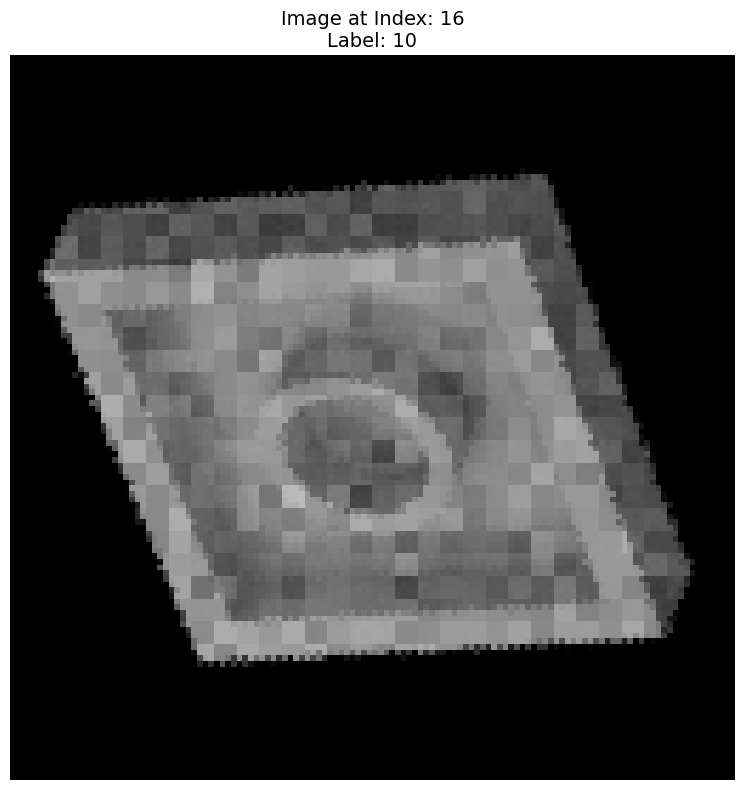

INFERENCE RESULTS FOR IMAGE INDEX 16 (TFLITE UINT8)
True Label:      10
Predicted Class: 10
Confidence:      91.45%
Correct:         ✓ YES

Top 5 Predictions:
→ 1. Class 10: 91.45%
  2. Class  4:  3.03%
  3. Class 13:  2.92%
  4. Class  9:  0.79%
  5. Class  7:  0.71%


/Users/ety/Documents/ai-master/2025/semester-1/edge-computing/.venv/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


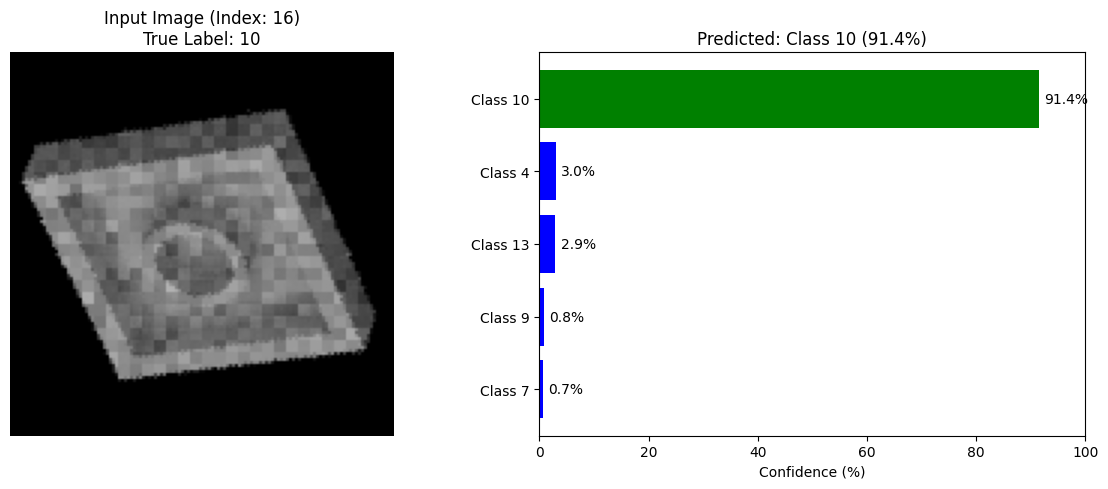

const uint8_t camera_image[16384] = {
      0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
      0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
      0,   0,   0,   0,   0,   0,   0,   0,  52,  95,  95, 104, 103, 103, 103, 103,
    105, 105, 105, 104,  84,  82,  82,  83, 106, 106, 106, 105, 104, 106, 106, 106,
     99,  99,  99,  82,  70,  19,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
      0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
      0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
      0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
      0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
      0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
      0,   0,   0,   0,   0,   0,   0,  46,  95,  95, 102, 104, 103, 103, 104, 104,
    105, 105, 104, 104,  82,  82,  82,

In [25]:
# Browse dataset
visualize_dataset(train_dataset, title="Training Data")

idx = 16

show_single_image(train_dataset, index=idx)

# Pick an image and test it
test_tflite_inference("lego_model.tflite", train_dataset, index=idx)

# You can also test the same image you exported for Arduino
export_image_array(train_dataset, index=15)